In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from scipy.spatial.distance import pdist

In [2]:
training_configs = np.load("LJ13_configs.npy")

In [3]:
com = training_configs.mean(axis=1, keepdims=True)

training_configs_centered = training_configs - com

In [4]:
training_configs_centered_tensor = torch.tensor(training_configs_centered, dtype=torch.float32)

print(training_configs_centered_tensor.shape)

torch.Size([24994, 13, 3])


In [5]:
class MessageMLP(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2*hidden_dim + 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU()
        )

    def forward(self, x):
        return self.net(x)

In [6]:
class FeatureMLP(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2*hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
class CoordMLP(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2*hidden_dim + 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

        torch.nn.init.xavier_uniform_(
            self.net[-1].weight,
            gain=0.001
        )

        torch.nn.init.zeros_(
            self.net[-1].bias
        )

    def forward(self, x):
        return self.net(x)

In [8]:
class EGNNLayer(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.message_mlp = MessageMLP(hidden_dim)

        self.feature_mlp = FeatureMLP(hidden_dim)

        self.coord_mlp = CoordMLP(hidden_dim)

    def forward(self, x, h, log_sigma):

        N = x.shape[1]

        diff = x[:,:,None,:] - x[:,None,:,:]
        dist2 = (diff**2).sum(dim=-1, keepdim=True)

        hi = h[:,:,None,:]
        hi = hi.expand(-1,-1,N,-1)

        hj = h[:,None,:,:]
        hj = hj.expand(-1,N,-1,-1)

        log_sigma_pair = log_sigma[:,None,None,:]
        log_sigma_pair = log_sigma_pair.expand(-1,N,N,-1)

        message_input = torch.cat([hi, hj, dist2, log_sigma_pair], dim=-1)

        messages = self.message_mlp(message_input)

        agg_messages = messages.sum(dim=2)

        feature_input = torch.cat([h, agg_messages], dim=-1)

        feature_update = self.feature_mlp(feature_input)

        h_new = h + feature_update

        coord_weights = self.coord_mlp(message_input)

        coord_update = diff * coord_weights

        delta_x = coord_update.sum(dim=2)

        delta_x = delta_x / x.shape[1]

        x_new = x + delta_x

        return x_new, h_new, delta_x

    

In [9]:
class ScoreNetwork(nn.Module):

    def __init__(
        self,
        hidden_dim=64,
        num_layers=3
    ):
        super().__init__()

        self.embedding = nn.Linear(1, hidden_dim)

        self.layers = nn.ModuleList(
            [
                EGNNLayer(hidden_dim)
                for _ in range(num_layers)
            ]
        )


    def forward(self, x, log_sigma):

        atom_features = torch.ones(x.shape[0], x.shape[1], 1)

        h = self.embedding(atom_features)

        f_pred = torch.zeros_like(x)

        for layer in self.layers:

            x, h, delta_x = layer(x, h, log_sigma)

            f_pred = f_pred + delta_x

        f_pred = f_pred - f_pred.mean(dim=1, keepdim=True)


        return f_pred


In [17]:
X = training_configs_centered.reshape(training_configs_centered.shape[0],39)
X = torch.tensor(X, dtype=torch.float32)

X_np = X.cpu().numpy()

sigma_max = pdist(X_np).max()
sigma_min = 0.02

print("sigma_max:", sigma_max)

sigma_max: 6.440439591617135


In [18]:
def get_sigma(t):

    return sigma_min * (sigma_max/sigma_min)**t

In [19]:
def train_model(
  optimizer_name="Adam",
  lr = 1e-4,
  batch_size = 100,
  width = 64,
  depth = 3,
  num_epochs = 600   
):
    dataset = TensorDataset(training_configs_centered_tensor)

    loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

    model = ScoreNetwork(hidden_dim=width,num_layers=depth)

    if optimizer_name == "Adam":
        
        optimizer=optim.Adam(
            model.parameters(),
            lr=lr
        )
    else:

        optimizer = optim.SGD(
            model.parameters(),
            lr=lr
        )
    

    loss_history = []

    for epoch in range(num_epochs):
        
        epoch_loss = 0.0

        for (x_batch,) in loader:
            
            batch_size_current = x_batch.shape[0]
            
            t = torch.rand(batch_size_current,1)

            sigma = get_sigma(t)

            sigma_expanded = sigma.view(-1,1,1)

            z = torch.randn_like(x_batch)

            z = z - z.mean(dim=1, keepdim=True)
            
            x_noisy = x_batch + sigma_expanded * z

            log_sigma = torch.log(sigma)
            
            target = -z  

            f_pred = model(x_noisy, log_sigma)

            loss_per_sample = ((f_pred - target) ** 2).sum(dim=(1,2))

            #weights = sigma.squeeze() ** 2

            loss = (loss_per_sample).mean()

            optimizer.zero_grad()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()
            
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:4d} | Loss = {avg_loss:.6f}")

    return model, loss_history

In [14]:
model, loss_history = train_model()

Epoch    0 | Loss = 23.783605
Epoch   10 | Loss = 13.839776
Epoch   20 | Loss = 11.859577
Epoch   30 | Loss = 12.017197
Epoch   40 | Loss = 11.933888
Epoch   50 | Loss = 11.224553
Epoch   60 | Loss = 11.182217
Epoch   70 | Loss = 11.144262
Epoch   80 | Loss = 10.845816
Epoch   90 | Loss = 10.686170
Epoch  100 | Loss = 10.663939
Epoch  110 | Loss = 10.533498
Epoch  120 | Loss = 10.602551
Epoch  130 | Loss = 10.538854
Epoch  140 | Loss = 10.508999
Epoch  150 | Loss = 10.357957
Epoch  160 | Loss = 10.405449
Epoch  170 | Loss = 10.255960
Epoch  180 | Loss = 10.444464
Epoch  190 | Loss = 10.343095
Epoch  200 | Loss = 10.342046
Epoch  210 | Loss = 10.396323
Epoch  220 | Loss = 10.307908
Epoch  230 | Loss = 10.181184
Epoch  240 | Loss = 10.249450
Epoch  250 | Loss = 10.187300
Epoch  260 | Loss = 10.218002
Epoch  270 | Loss = 10.277536
Epoch  280 | Loss = 10.241470
Epoch  290 | Loss = 10.178445
Epoch  300 | Loss = 10.287551
Epoch  310 | Loss = 10.154851
Epoch  320 | Loss = 10.157790
Epoch  330

In [13]:
torch.save(model.state_dict(), "lj13_f_theta_strategy_1.pth")

NameError: name 'model' is not defined

In [20]:
model = ScoreNetwork(hidden_dim=64, num_layers=3)

model.load_state_dict(torch.load("lj13_f_theta_strategy_1.pth"))

model.eval()

ScoreNetwork(
  (embedding): Linear(in_features=1, out_features=64, bias=True)
  (layers): ModuleList(
    (0-2): 3 x EGNNLayer(
      (message_mlp): MessageMLP(
        (net): Sequential(
          (0): Linear(in_features=130, out_features=64, bias=True)
          (1): SiLU()
          (2): Linear(in_features=64, out_features=64, bias=True)
          (3): SiLU()
        )
      )
      (feature_mlp): FeatureMLP(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=64, bias=True)
          (1): SiLU()
          (2): Linear(in_features=64, out_features=64, bias=True)
        )
      )
      (coord_mlp): CoordMLP(
        (net): Sequential(
          (0): Linear(in_features=130, out_features=64, bias=True)
          (1): SiLU()
          (2): Linear(in_features=64, out_features=64, bias=True)
          (3): SiLU()
          (4): Linear(in_features=64, out_features=1, bias=True)
        )
      )
    )
  )
)

Text(0, 0.5, 'Loss')

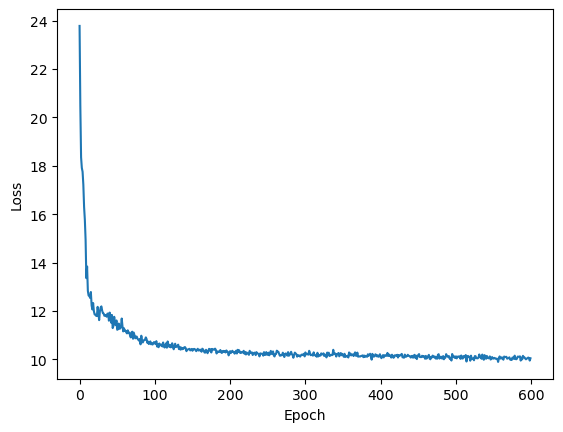

In [16]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")

The loss is now roughly 12.2 (against a baseline of 36, since it is now in the COM-free subspace)
and it captures roughly 66% of the noise variance as opposed to 61% as in the previous model

It is quite clear that the model struggles to achieve the target at low sigma values, esp 0.01

In [32]:
sigma_min_sampling = 0.01

def get_sigma_sampling(t):

    return sigma_min_sampling * (sigma_max/sigma_min_sampling)**t

In [33]:
def g(t):

    sigma = get_sigma_sampling(t)

    return (sigma * np.sqrt(2*np.log(sigma_max/sigma_min_sampling)))

In [34]:
def predictor_corrector_sampler(
    model,
    n_samples=1000,
    n_steps=1000,
    n_corrector=1,
    snr=0.16
):

    model.eval()

    x = torch.randn(n_samples, 13, 3)
    x = x - x.mean(dim=1, keepdim=True)
    x = x * sigma_max

    dt = 1.0 / n_steps
    sqrt_dt = np.sqrt(dt)


    with torch.no_grad():

        for i in range(n_steps):

            t = 1 - i / n_steps

            t_tensor = torch.full((n_samples,1), t)

            sigma = get_sigma_sampling(t_tensor)
            log_sigma = torch.log(sigma)

            g_val = g(t_tensor).view(-1, 1, 1)

            f_pred = model(x, log_sigma)

            score = f_pred / sigma.view(-1, 1, 1)

            if torch.isnan(score).any():
                    print(f"NaN in score at step {i}, t={t:.4f}, sigma={sigma[0].item():.4f}")
                    
                    break

            noise = torch.randn_like(x)

            noise = noise - noise.mean(dim=1, keepdim=True)

            x = (x + (g_val**2) * score * dt + g_val * sqrt_dt * noise)

            
            if torch.isnan(x).any():
                    print(f"NaN in x (predictor) at step {i}")
                    break

            for _ in range(n_corrector):

                f_pred = model(x, log_sigma)

                score = f_pred / sigma.view(-1, 1, 1)

                noise = torch.randn_like(x)

                noise = noise - noise.mean(dim=1, keepdim=True)

                score_norm = torch.norm(score.reshape(n_samples, -1), dim=1).mean()

                noise_norm = torch.norm(noise.reshape(n_samples,-1), dim=1).mean()

                if score_norm.item() == 0.0 or torch.isnan(score_norm):
                        print(f"score_norm degenerate at step {i}: {score_norm.item()}")
                        break

                eps = (2 * (snr * noise_norm / score_norm)**2)
                #eps = torch.clamp(eps, max=0.05)       

                x = (x + eps * score + torch.sqrt(2*eps) * noise)

                if torch.isnan(x).any():
                        print(f"NaN in x (corrector) at step {i}")
                        break


    return x

In [35]:
samples = predictor_corrector_sampler(
    model,
    n_samples=1000,
    n_steps=1000,
    n_corrector=1,
    snr=0.16
)

In [18]:
print("NaNs present:", torch.isnan(samples).any().item())
print("Infs present:", torch.isinf(samples).any().item())
print("Sample range:", samples.min().item(), samples.max().item())
print("COM check:", samples.mean(dim=1).abs().max().item())

NaNs present: False
Infs present: False
Sample range: -1.2142521142959595 1.1933451890945435
COM check: 4.56434008810902e-06


In [36]:
def lj_energy(coords):

    N = coords.shape[0]

    energy = 0.0

    for i in range(N):
        for j in range(i + 1, N):

            r = torch.norm(coords[i] - coords[j])

            inv_r6 = (1.0 / r) ** 6
            inv_r12 = inv_r6 ** 2

            energy += 4 * (inv_r12 - inv_r6)

    return energy

In [37]:
generated_energies = []

for sample in samples:

    E = lj_energy(sample)

    generated_energies.append(E.item())

generated_energies = np.array(generated_energies)

In [38]:
training_energies = []

for sample in training_configs_centered_tensor:

    E = lj_energy(sample)

    training_energies.append(E.item())

training_energies = np.array(training_energies)

In [39]:
print("Training")
print(training_energies.min())
print(training_energies.max())
print(training_energies.mean())

print()

print("Generated")
print(generated_energies.min())
print(generated_energies.max())
print(generated_energies.mean())

Training
-43.76762771606445
-40.26786804199219
-42.526261944498756

Generated
-43.72272872924805
-38.939300537109375
-42.32637240600586


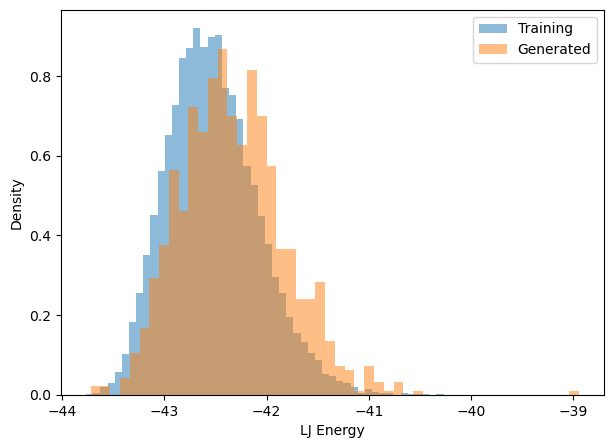

In [40]:
plt.figure(figsize=(7,5))

plt.hist(training_energies,
         bins=50,
         density=True,
         alpha=0.5,
         label="Training")

plt.hist(generated_energies,
         bins=50,
         density=True,
         alpha=0.5,
         label="Generated")

plt.xlabel("LJ Energy")
plt.ylabel("Density")
plt.legend()
plt.show()

In [41]:
mean_U_generated = np.mean(generated_energies)
print("Mean U generated:", mean_U_generated)

Mean U generated: -42.32637240600586


In [42]:
U_min = -44.3268

T_eff_generated = (mean_U_generated - U_min) / (33 / 2)

print("Generated T_eff:", T_eff_generated)

Generated T_eff: 0.1212380359996448


The T_eff of the new model (with both 1/sigma parametrization and imposing a COM-free subspace) has reduced compared to the 0.1434 we measured for the previous model

In [43]:
def pairwise_distances(configs):

    distances = []

    for config in configs:

        for i in range(13):
            for j in range(i+1,13):

                r = torch.norm(config[i]-config[j])

                distances.append(r.item())

    return np.array(distances)

In [44]:
training_distances = pairwise_distances(training_configs_centered_tensor)

generated_distances = pairwise_distances(samples)

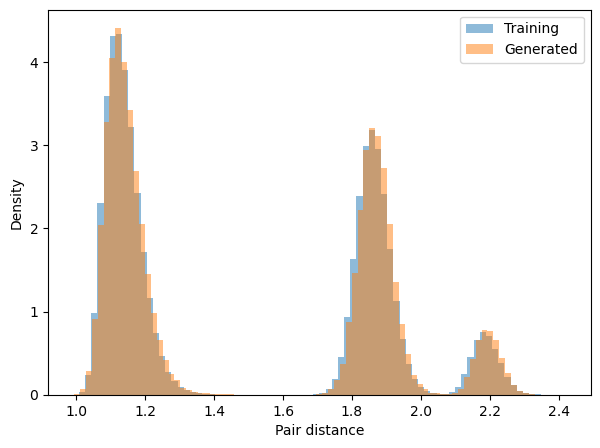

In [45]:
plt.figure(figsize=(7,5))

plt.hist(
    training_distances,
    bins=80,
    density=True,
    alpha=0.5,
    label="Training"
)

plt.hist(
    generated_distances,
    bins=80,
    density=True,
    alpha=0.5,
    label="Generated"
)

plt.xlabel("Pair distance")
plt.ylabel("Density")
plt.legend()

plt.show()

The mean learned norm has reduced from 23.9% to 18.5%

In [46]:
def lj_energy_batch(coords):
    # coords shape: [batch, N, 3]

    diff = coords[:, :, None, :] - coords[:, None, :, :]

    # Pairwise distances
    r = torch.norm(diff, dim=-1)

    # Only take i < j
    i, j = torch.triu_indices(
        coords.shape[1],
        coords.shape[1],
        offset=1,
        device=coords.device
    )

    r_pairs = r[:, i, j]

    inv_r6 = (1.0 / r_pairs) ** 6
    inv_r12 = inv_r6 ** 2

    energy = 4 * (inv_r12 - inv_r6)

    # Sum over all 78 pairs
    return energy.sum(dim=1)

In [47]:
def langevin_push(
    samples,
    n_steps=100,
    step_size=1e-5,
    temperature=0.1
):

    beta = 1.0 / temperature

    x = samples.clone().detach()

    sqrt_2eps = np.sqrt(2.0 * step_size)

    for step in range(n_steps):

        x.requires_grad_(True)

        # LJ energy for all configurations
        energy = lj_energy_batch(x)

        # Gradient for all configurations
        grad_U = torch.autograd.grad(
            energy.sum(),
            x
        )[0]

        # Force
        force = -grad_U

        # Thermal noise
        noise = torch.randn_like(x)

        # Remove center-of-mass motion
        noise = noise - noise.mean(
            dim=1,
            keepdim=True
        )

        with torch.no_grad():

            x = (
                x
                + step_size * beta * force
                + sqrt_2eps * noise
            )

            # Keep COM = 0
            x = x - x.mean(
                dim=1,
                keepdim=True
            )

    return x.detach()

In [69]:
samples_200 = langevin_push(
    samples,
    n_steps=200,
    step_size=1e-5,
    temperature=0.1
)

In [70]:
generated_energies_new = []

for sample in samples_200:

    E = lj_energy(sample)

    generated_energies_new.append(E.item())

generated_energies_new = np.array(generated_energies_new)

In [71]:
print("Training")
print(training_energies.min())
print(training_energies.max())
print(training_energies.mean())
print("Generated New")
print(generated_energies_new.min())
print(generated_energies_new.max())
print(generated_energies_new.mean())

Training
-43.76762771606445
-40.26786804199219
-42.526261944498756
Generated New
-43.69053268432617
-38.50373840332031
-42.48039900970459


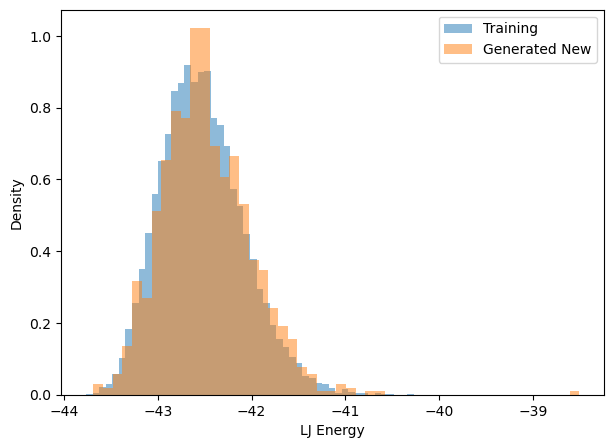

In [72]:
plt.figure(figsize=(7,5))

plt.hist(training_energies,
         bins=50,
         density=True,
         alpha=0.5,
         label="Training")

plt.hist(generated_energies_new,
         bins=50,
         density=True,
         alpha=0.5,
         label="Generated New")

plt.xlabel("LJ Energy")
plt.ylabel("Density")
plt.legend()
plt.show()

In [73]:
mean_U_generated_new = np.mean(generated_energies_new)
print("Mean U generated:", mean_U_generated_new)

Mean U generated: -42.48039900970459


In [74]:
U_min = -44.3268

T_eff_generated_new = (mean_U_generated_new - U_min) / (33 / 2)

print("Generated T_eff_new:", T_eff_generated_new)

Generated T_eff_new: 0.11190309032093379


Based on observations, the best sigma_min_training and sigma_min_sampling values were chosen and the Langevin refinement applied to the samples (200 steps). 
The new effective temperature is 0.1119 which is approximately 2.66% further away from the training dataset effective temperature (0.109)

In [75]:
generated_distances_new = pairwise_distances(samples_200)

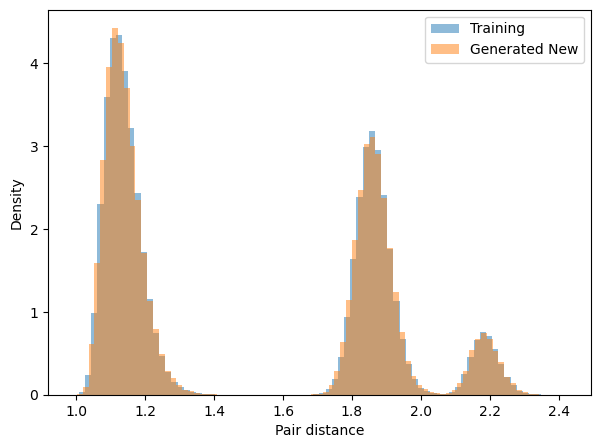

In [76]:
plt.figure(figsize=(7,5))

plt.hist(
    training_distances,
    bins=80,
    density=True,
    alpha=0.5,
    label="Training"
)

plt.hist(
    generated_distances_new,
    bins=80,
    density=True,
    alpha=0.5,
    label="Generated New"
)

plt.xlabel("Pair distance")
plt.ylabel("Density")
plt.legend()

plt.show()